# 异质性处理效应教程

### 平均效应之外，对谁更有效

平均处理效应回答「这项政策平均而言有没有用」。很多决策需要的是下一个问题的答案，**对谁有用**。一种药对一部分病人疗效显著，对另一部分无效甚至有害。一项补贴对低收入家庭效果很大，对高收入家庭几乎没有。平均数把这些差别都抹平了。

估计异质性效应比估计平均效应难得多。个体的因果效应永远观测不到，机器学习方法又很擅长从噪声里找出看似有意义的模式。所以这份教程的重点有两个，一是怎么估计，二是**怎么判断估计出来的异质性是真的**。

教程使用一份真值已知的模拟数据，这样每一步都能和正确答案对照。全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 条件平均处理效应 | CATE 是什么，为什么难估 |
| 2 | 一份真值已知的数据 | 效应怎样随特征变化 |
| 3 | 从交互项说起 | 传统做法及其局限 |
| 4 | 元学习器 | S、T、X、R、DR 五种思路 |
| 5 | 因果森林 | 专为 CATE 设计的森林，袋外预测 |
| 6 | 异质性是真的吗 | 校准检验与 RATE，以及一个必须避开的陷阱 |
| 7 | 效应随什么变化 | 变量重要性、最佳线性投影、分组效应 |
| 8 | 从效应到决策 | 策略树，谁该接受处理 |
| 9 | 小结 | 一份清单 |

## 1. 条件平均处理效应

设 $Y(1)$ 和 $Y(0)$ 是潜在结果，$X$ 是处理前的特征。**条件平均处理效应**（CATE）是特征为 $x$ 的人群的平均效应。

$$
\tau(x) = E\big[Y(1) - Y(0) \mid X = x\big].
$$

平均处理效应是它在总体上的平均，$ATE = E[\tau(X)]$。

识别 CATE 需要的假设与识别 ATE 相同，条件独立和重叠。难的是估计。

- 估计 ATE 是估计**一个数**，可以用上全部样本。估计 CATE 是估计**一个函数**，在特征空间的每个局部能用的样本都很少。
- 预测问题有真实的标签可以对答案。CATE 没有，任何一个人都只观测到 $Y(1)$ 和 $Y(0)$ 中的一个。普通的交叉验证用不上。
- 灵活的模型会把噪声当成异质性。即使真实效应对所有人完全相同，估计出来的 $\hat\tau(x)$ 也会有高有低。

第三点决定了本教程后半部分的内容。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 2. 一份真值已知的数据

生成 3,000 个观测，5 个相互独立的特征。真实的处理效应是

$$
\tau(x) = 1 + 1.5 \cdot \mathbb{1}\{x_1 > 0\} + 0.5\, x_3 .
$$

效应随 $x_1$ 有一个跳跃，随 $x_3$ 线性变化，与 $x_2$、$x_4$、$x_5$ 无关。

数据不是随机实验。接受处理的概率取决于 $x_2$，而 $x_2$ 也直接影响结果，所以它是混淆变量。结果方程里还有 $x_4$ 的一个非线性项。

In [2]:
rng = np.random.default_rng(0)
n = 3000
covs = ["x1", "x2", "x3", "x4", "x5"]

X = rng.normal(size=(n, 5))
propensity = 1 / (1 + np.exp(-0.6 * X[:, 1]))              # 处理概率取决于 x2
d = rng.binomial(1, propensity)
tau = 1 + 1.5 * (X[:, 0] > 0) + 0.5 * X[:, 2]              # 真实的个体层面 CATE
y = X[:, 1] + 0.5 * X[:, 3] ** 2 + tau * d + rng.normal(size=n)

df = pd.DataFrame(X, columns=covs)
df["d"], df["y"], df["tau"] = d, y, tau

print(f"真实 ATE = {tau.mean():.3f}")
print(f"真实 CATE 的范围: {tau.min():.2f} 到 {tau.max():.2f}，标准差 {tau.std():.2f}")

naive = df.loc[df.d == 1, "y"].mean() - df.loc[df.d == 0, "y"].mean()
print(f"原始均值差 = {naive:.3f}  (受 x2 混淆，偏高)")

真实 ATE = 1.740
真实 CATE 的范围: -0.63 到 4.47，标准差 0.90
原始均值差 = 2.315  (受 x2 混淆，偏高)


## 3. 从交互项说起

检验异质性最传统的办法是在回归里加入处理变量与特征的交互项。

In [3]:
inter = sp.regress("y ~ d * (x1 + x2 + x3 + x4 + x5)", data=df, robust="hc1")
inter.tidy().query("term.str.startswith('d')")[["term", "estimate", "std_error", "p_value"]].round(3)

,term,estimate,std_error,p_value
1,d,1.713,0.048,0.000
7,d:x1,0.611,0.048,0.000
8,d:x2,0.058,0.049,0.231
9,d:x3,0.501,0.048,0.000
10,d:x4,0.066,0.072,0.360
11,d:x5,0.021,0.044,0.638


交互项 `d:x1` 和 `d:x3` 显著，其余三个不显著，方向是对的。事先知道该看哪几个特征、关系又大致是线性的时候，这个办法简单透明。

它有两个局限。

- **函数形式要事先设定**。真实效应在 $x_1 = 0$ 处是一个跳跃，线性交互项只能用一条斜线去近似它。
- **特征多了就做不动**。20 个特征两两交互就是 190 项，再加上非线性，回归式会迅速膨胀，多重检验的问题也随之而来。

机器学习方法让数据自己决定函数形式。下面依次介绍两类。

## 4. 元学习器

元学习器（meta-learner）是一类配方。它们把估计 CATE 拆成几个普通的预测问题，每个预测问题可以交给任何一种机器学习模型。

| 学习器 | 做法 | 特点 |
| --- | --- | --- |
| **S** | 把处理变量当作一个普通特征，拟合一个模型 $\mu(x, d)$，再算 $\mu(x,1) - \mu(x,0)$ | 简单。模型可能忽视处理变量，把效应压向 0 |
| **T** | 处理组和对照组各拟合一个模型，相减 | 直观。两个模型各自的误差会叠加 |
| **X** | 在 T 的基础上，用一组的模型为另一组插补个体效应，再对插补值建模 | 两组样本量悬殊时表现好 |
| **R** | 先把 $Y$ 和 $D$ 对 $X$ 的预测部分扣掉，再对残差之间的关系建模 | 对混淆稳健，直接以 CATE 为目标 |
| **DR** | 构造双重稳健的伪结果，再对它建模 | 结果模型和倾向得分模型只要对一个 |

`sp.metalearner` 用同一个接口提供这五种。下面这个单元格需要半分钟左右。

In [4]:
learners = {}
rows = []
for name in ("s", "t", "x", "r", "dr"):
    fit = sp.metalearner(df, y="y", treat="d", covariates=covs, learner=name, n_bootstrap=0)
    cate = sp.predict_cate(fit, df)
    learners[name] = cate
    rows.append({
        "learner": name.upper(),
        "ATE": fit.estimate,
        "CATE RMSE vs truth": np.sqrt(np.mean((cate - tau) ** 2)),
        "correlation with truth": np.corrcoef(cate, tau)[0, 1],
    })

print(f"真实 ATE = {tau.mean():.3f}")
pd.DataFrame(rows).round(3)

真实 ATE = 1.740


,learner,ATE,CATE RMSE vs truth,correlation with truth
0,S,1.663,0.337,0.929
1,T,1.663,0.547,0.863
2,X,1.663,0.289,0.956
3,R,1.663,0.424,0.911
4,DR,1.663,0.525,0.867


两点观察。

- 五种学习器报告的 **ATE 相同**。`sp.metalearner` 的平均效应统一用双重稳健的 AIPW 公式计算，并给出有效的标准误，不取决于用哪种学习器估计 CATE。它已经去掉了 $x_2$ 的混淆，与真值的差距在 1.5 个标准误左右。
- **CATE 的精度各不相同**。在这份数据上 X 学习器和 S 学习器的误差最小。这个排名不具有一般性，换一个数据生成过程名次就会变。没有哪一种学习器总是最好。

在真实数据上没有 `tau` 这一列，上面的 RMSE 算不出来。第 6 节介绍不需要真值的评估办法。

## 5. 因果森林

因果森林（Wager and Athey 2018；Athey, Tibshirani and Wager 2019）是专门为估计 CATE 设计的随机森林。它和普通随机森林有三处关键的不同。

- **分裂准则不同**。普通的回归树分裂是为了让叶子里的结果更接近，因果树分裂是为了让两个子节点的**处理效应差别最大**。
- **诚实估计**（honesty）。每棵树把样本一分为二，一半用来决定怎么分裂，另一半用来估计叶子里的效应。这避免了用同一批数据既选结构又估效应带来的过拟合，也是置信区间有效的前提。
- **先正交化**。先把 $Y$ 和 $D$ 中能被 $X$ 预测的部分扣掉，再在残差上长树，这一步处理混淆。

公式的写法是 `结果 ~ 处理 | 特征`。

In [5]:
cf = sp.causal_forest("y ~ d | x1 + x2 + x3 + x4 + x5", data=df, n_estimators=1000, random_state=0)

ate = cf.average_treatment_effect()
print(f"因果森林的 ATE: {ate['estimate']:.3f}  (se {ate['se']:.3f})    真值 {tau.mean():.3f}")
print(f"估计的倾向得分范围: {ate['pscore_min']:.2f} 到 {ate['pscore_max']:.2f}")

因果森林的 ATE: 1.722  (se 0.046)    真值 1.740
估计的倾向得分范围: 0.21 到 0.83


### 袋外预测

在训练样本上评估 CATE 时，必须用**袋外**（out-of-bag）预测。每个观测的预测只来自那些没有用到它的树。直接对训练数据调用 `cf.effect(X)` 会用到见过这个观测的树，预测显得比实际更准。

CATE 的 RMSE: 0.206
与真值的相关系数: 0.974


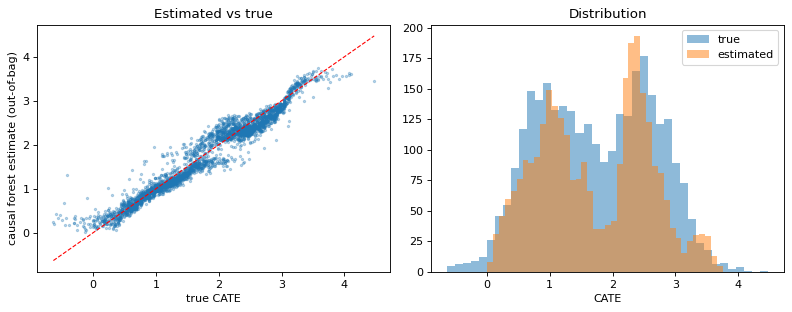

In [6]:
cate_cf = np.asarray(cf.oob_effect()).ravel()

print(f"CATE 的 RMSE: {np.sqrt(np.mean((cate_cf - tau) ** 2)):.3f}")
print(f"与真值的相关系数: {np.corrcoef(cate_cf, tau)[0, 1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(tau, cate_cf, s=4, alpha=0.3)
axes[0].plot([tau.min(), tau.max()], [tau.min(), tau.max()], "r--", lw=1)
axes[0].set_xlabel("true CATE")
axes[0].set_ylabel("causal forest estimate (out-of-bag)")
axes[0].set_title("Estimated vs true")

axes[1].hist(tau, bins=40, alpha=0.5, label="true")
axes[1].hist(cate_cf, bins=40, alpha=0.5, label="estimated")
axes[1].set_xlabel("CATE")
axes[1].legend()
axes[1].set_title("Distribution")
plt.tight_layout()
plt.show()

估计值紧贴 45 度线。右图里真实 CATE 是双峰分布（来自 $x_1$ 的跳跃），森林把它恢复出来了。

因果森林还能给每个点的估计配上置信区间。

In [7]:
new_points = pd.DataFrame(
    {"x1": [-1.0, 1.0, 1.0], "x2": [0.0, 0.0, 0.0], "x3": [0.0, 0.0, 1.5], "x4": [0.0, 0.0, 0.0], "x5": [0.0, 0.0, 0.0]}
)
point = np.asarray(cf.effect(new_points[covs].values)).ravel()
lower, upper = (np.asarray(a).ravel() for a in cf.effect_interval(new_points[covs].values))

out = new_points[["x1", "x3"]].copy()
out["true CATE"] = 1 + 1.5 * (out["x1"] > 0) + 0.5 * out["x3"]
out["estimate"], out["ci_lower"], out["ci_upper"] = point, lower, upper
out.round(2)

,x1,x3,true CATE,estimate,ci_lower,ci_upper
0,-1.0,0.0,1.00,1.03,0.69,1.37
1,1.0,0.0,2.50,2.34,2.01,2.66
2,1.0,1.5,3.25,3.47,3.00,3.93


单个点的置信区间比 ATE 的宽得多。这是 CATE 估计的常态，对个体层面的预测要保持谨慎。更可靠的用法是对**人群**下结论，下面两节都是这样做的。

## 6. 异质性是真的吗

真实数据里没有真值可以对照。森林总会给出一个有高有低的 $\hat\tau(x)$，哪怕真实效应处处相同。在解读之前先要回答，这些差别是信号还是噪声。

### 校准检验

把观测到的结果对两项做回归，一项是森林的平均预测，另一项是每个个体的预测与平均值之差。

- 第一项的系数接近 1，说明平均效应估得准。
- 第二项的系数显著大于 0，说明森林预测效应更大的人，效应确实更大。**这是存在异质性的证据**。系数接近 1 说明异质性的幅度也估得准。

In [8]:
cal = sp.calibrate_cate(cf)
print(cal["calibration"][["coef", "se", "p_one_sided"]].round(4))
print("\n检测到异质性:", cal["heterogeneity_detected"])

                                  coef      se  p_one_sided
mean_forest_prediction          1.0001  0.0243          0.0
differential_forest_prediction  1.0631  0.0495          0.0

检测到异质性: True


### RATE

RATE（Yadlowsky et al. 2025）问的是一个更贴近决策的问题。如果按照 $\hat\tau(x)$ 从高到低给人群排序，优先处理排在前面的人，比随机挑人好多少？

排序有用，RATE 为正。排序没有信息，RATE 为 0。它检验的是**排序**的质量，不要求 CATE 的数值准确。

这里有一个必须避开的陷阱。**不能用同一个森林在同一批数据上既排序又评估**。排序本身是从这批数据的结果里学出来的，用它去评估自己，即使没有任何真实的异质性，RATE 也会偏正。`sp.rate_split` 把数据分成两半，一半拟合森林并排序，另一半评估，重复多次并汇总。

下面这个单元格要重新拟合若干次森林，需要一分钟左右。

In [9]:
rate = sp.rate_split(cf, n_splits=11, random_state=0)
print(f"RATE (AUTOC) = {rate['estimate']:.3f}  (se {rate['se']:.3f})")
print(f"95% 置信区间: [{rate['ci_low']:.3f}, {rate['ci_high']:.3f}]")

RATE (AUTOC) = 0.777  (se 0.079)
95% 置信区间: [0.615, 0.977]


置信区间远离 0。按森林的预测排序，确实能把效应更大的人找出来。

为了看清楚这个检验的价值，做一个对照实验。把数据改成**效应对所有人都相同**，其余不变，再跑同样的流程。

In [10]:
df_null = df.copy()
df_null["y"] = X[:, 1] + 0.5 * X[:, 3] ** 2 + tau.mean() * d + rng.normal(size=n)   # 同质效应

cf_null = sp.causal_forest("y ~ d | x1 + x2 + x3 + x4 + x5", data=df_null, n_estimators=1000, random_state=0)
cate_null = np.asarray(cf_null.oob_effect()).ravel()
rate_null = sp.rate_split(cf_null, n_splits=11, random_state=0)
cal_null = sp.calibrate_cate(cf_null)

print(f"真实 CATE 的标准差          : 0  (所有人都是 {tau.mean():.2f})")
print(f"森林估计的 CATE 的标准差    : {cate_null.std():.3f}")
print(f"森林估计的 CATE 的范围      : {cate_null.min():.2f} 到 {cate_null.max():.2f}")
print(f"\nRATE = {rate_null['estimate']:.3f},  95% 置信区间 [{rate_null['ci_low']:.3f}, {rate_null['ci_high']:.3f}]")
print("校准检验检测到异质性:", cal_null["heterogeneity_detected"])

真实 CATE 的标准差          : 0  (所有人都是 1.74)
森林估计的 CATE 的标准差    : 0.082
森林估计的 CATE 的范围      : 1.40 到 2.05

RATE = 0.004,  95% 置信区间 [-0.165, 0.152]
校准检验检测到异质性: False


真实效应没有任何差别，森林的估计值仍然有一定的散布。如果只看 $\hat\tau(x)$ 的直方图，很容易以为发现了异质性。RATE 的置信区间包含 0，校准检验也没有检测到异质性，两者都正确地指出这些差别只是噪声。

**先做检验，再做解读**。这是异质性分析最重要的一条纪律。

## 7. 效应随什么变化

确认存在异质性之后，下一个问题是它与哪些特征有关。

### 变量重要性

变量重要性统计的是森林在各个特征上分裂的频率，越靠近树根的分裂权重越大。

In [11]:
importance = cf.variable_importance()
importance.round(3)

x1    0.630
x2    0.038
x3    0.237
x4    0.044
x5    0.052
Name: importance, dtype: float64

森林把分裂集中在 $x_1$ 和 $x_3$ 上，正是真实效应依赖的两个特征。$x_2$ 是混淆变量，$x_4$ 强烈影响结果的水平，但它们都不影响**效应**，重要性很低。

变量重要性只说明森林用了哪些变量，不带方向，也没有标准误。它适合用来筛选，不适合用来下结论。

### 最佳线性投影

最佳线性投影（best linear projection）把 CATE 投影到一组特征上，得到一个带标准误的线性概括。

$$
\tau(x) \approx \beta_0 + \beta_1 x_1 + \dots + \beta_5 x_5 .
$$

它用的是双重稳健得分，所以系数的推断是有效的，不依赖森林的 CATE 估计是否准确。

In [12]:
sp.best_linear_projection(cf, A=df[covs]).round(3)

,coef,se,t,p,ci_lower,ci_upper
Intercept,1.717,0.043,39.796,0.000,1.633,1.802
x1,0.616,0.043,14.193,0.000,0.531,0.701
x2,0.015,0.045,0.324,0.746,-0.074,0.104
x3,0.524,0.047,11.173,0.000,0.432,0.616
x4,0.050,0.059,0.849,0.396,-0.065,0.166
x5,0.009,0.043,0.204,0.839,-0.076,0.094


$x_1$ 和 $x_3$ 的系数显著，其余三个接近 0。$x_3$ 的系数接近真值 0.5。$x_1$ 的真实关系是一个跳跃，线性投影用一条斜线去概括它，所以系数没有直接对应的真值，但方向和显著性是对的。

### 分组效应

把样本按估计的 CATE 从低到高分成四组，分别估计每一组的平均效应。如果森林的排序有意义，各组的效应应该依次升高。这里同样要用袋外预测来分组。

In [13]:
groups = pd.qcut(cate_cf, 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
group_table = sp.forest_group_effects(cf, by=np.asarray(groups))
group_table["true mean CATE"] = df.groupby(groups, observed=True)["tau"].mean().reindex(group_table.index).values
group_table.round(3)

,n_rows,n_units,estimate,se,z,p,ci_low,ci_high,forest_mean,true mean CATE
group,,,,,,,,,,
Q1 (lowest),750,750,0.614,0.083,7.379,0.0,0.451,0.777,0.631,0.598
Q2,750,750,1.274,0.079,16.100,0.0,1.119,1.429,1.280,1.362
Q3,750,750,2.138,0.088,24.395,0.0,1.966,2.310,2.184,2.170
Q4 (highest),750,750,2.861,0.092,31.115,0.0,2.681,3.041,2.802,2.830


四组的估计效应依次升高，每一组都贴近该组真实 CATE 的均值。

## 8. 从效应到决策

估计异质性的最终目的常常是决定**对谁实施处理**。假设处理有成本，每处理一个人要花费 2 个单位。只有效应超过 2 的人才值得处理。

最直接的规则是「$\hat\tau(x) > 2$ 就处理」。但这个规则是一个黑箱，难以解释，也难以执行。**策略树**（Athey and Wager 2021）在浅层决策树这类简单规则里直接寻找使总收益最大的那一个。

把成本从接受处理者的结果里扣掉，再让策略树去找最优规则。

In [14]:
COST = 2.0
df["y_net"] = df["y"] - COST * df["d"]

policy = sp.policy_tree(df, y="y_net", treat="d", covariates=covs, depth=2)
print(policy)

Policy Tree (Athey-Wager 2021)
----------------------------------------
  Max depth          : 2
  Policy covariates  : x1, x2, x3, x4, x5
  Observations       : 3,000
  Fraction treated   : 0.452
  V(treat all)       : -0.3037
  V(treat none)      : +0.0000
  V(learned policy)  : +0.2761  (SE 0.0318, 95% CI [+0.2137, +0.3384])
  Value gain vs best uniform : +0.2761

Learned policy:
IF x3 <= -1.0894:
  IF x1 <= 0.9029:
    DON'T TREAT (n=332, avg_benefit=-1.5924)
  ELSE (x1 > 0.9029):
    TREAT (n=55, avg_benefit=0.3441)
ELSE (x3 > -1.0894):
  IF x1 <= -0.0100:
    DON'T TREAT (n=1313, avg_benefit=-0.9219)
  ELSE (x1 > -0.0100):
    TREAT (n=1300, avg_benefit=0.6225)



学到的规则可以直接读出来。它的主要分裂落在 $x_1$ 和 $x_3$ 上。

模拟数据里可以算出任何规则的真实价值，把它和几个基准比较。

In [15]:
net_benefit = tau - COST                    # 每个人接受处理的真实净收益

def policy_value(treat_mask):
    """一条规则的真实人均净收益。"""
    return float(np.mean(net_benefit * treat_mask))

assign = np.asarray(policy["policy"]).astype(bool)   # 策略树对每个人的处理决定

rows = [
    ("treat nobody", 0.0, 0.0),
    ("treat everybody", policy_value(np.ones(n, dtype=bool)), 1.0),
    ("causal forest: treat if estimated CATE > cost", policy_value(cate_cf > COST), float(np.mean(cate_cf > COST))),
    ("depth-2 policy tree", policy_value(assign), float(assign.mean())),
    ("oracle: treat if true CATE > cost", policy_value(net_benefit > 0), float(np.mean(net_benefit > 0))),
]

pd.DataFrame(rows, columns=["rule", "true value per person", "share treated"]).round(3)

,rule,true value per person,share treated
0,treat nobody,0.000,0.000
1,treat everybody,-0.260,1.000
2,causal forest: treat if estimated CATE > cost,0.262,0.456
3,depth-2 policy tree,0.262,0.452
4,oracle: treat if true CATE > cost,0.270,0.433


对所有人都处理是亏的，平均效应低于成本。只处理一部分人则能获得正的净收益。

深度为 2 的策略树只用了两三个条件，价值已经接近知道真实效应的最优规则。简单规则损失的那一点价值，换来的是可以写在一页纸上、可以向决策者解释、可以审计的规则。

在真实数据上，规则的价值也要在**没有参与学习规则的样本**上评估，道理和第 6 节的 RATE 相同。

## 9. 小结

1. **识别假设与 ATE 相同**。条件独立和重叠。异质性分析不会让识别变得更容易。
2. **先问有没有异质性，再问是什么样的**。用校准检验（`sp.calibrate_cate`）和样本分割的 RATE（`sp.rate_split`）。只看 $\hat\tau(x)$ 的散布不算证据。
3. **训练样本上的一切评估都用袋外预测**（`cf.oob_effect()`）。
4. **不要用同一批数据既学排序又评估排序**。
5. **对人群下结论，不对个体下结论**。分组效应（`sp.forest_group_effects`）和最佳线性投影（`sp.best_linear_projection`）有可靠的标准误，单点的 CATE 区间很宽。
6. **变量重要性用来筛选，不用来下结论**。
7. **事先指定的分组分析仍然是最可信的**。机器学习找到的异质性是探索性的发现，最好在新数据上验证。
8. **要做决策时直接学规则**（`sp.policy_tree`），并在留出的样本上评估它的价值。

延伸阅读见 `docs/guides/grf_forests.md` 和 `docs/guides/choosing_ml_causal_estimator.md`。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [16]:
keys = [
    "kunzel2019metalearners",
    "nie2021quasi",
    "kennedy2023towards",
    "wager2018estimation",
    "athey2019generalized",
    "yadlowsky2025evaluating",
    "athey2021policy",
]
print(sp.bibtex(keys))

@article{kunzel2019metalearners,
  title={Metalearners for estimating heterogeneous treatment effects using machine learning},
  author={K{\"u}nzel, S{\"o}ren R. and Sekhon, Jasjeet S. and Bickel, Peter J. and Yu, Bin},
  journal={Proceedings of the National Academy of Sciences},
  volume={116},
  number={10},
  pages={4156--4165},
  year={2019},
  publisher={National Academy of Sciences},
  doi={10.1073/pnas.1804597116}
}

@article{nie2021quasi,
  title={Quasi-oracle estimation of heterogeneous treatment effects},
  author={Nie, Xinkun and Wager, Stefan},
  journal={Biometrika},
  volume={108},
  number={2},
  pages={299--319},
  year={2021},
  publisher={Oxford University Press},
  doi={10.1093/biomet/asaa076}
}

@article{kennedy2023towards,
  title={Towards optimal doubly robust estimation of heterogeneous causal effects},
  author={Kennedy, Edward H.},
  journal={Electronic Journal of Statistics},
  volume={17},
  number={2},
  pages={3008--3049},
  year={2023},
  publisher={Instit